In [1]:
import pandas as pd
import numpy as np
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy.stats import norm

In [2]:
%run ../codes/data_input.py
%run ../codes/phase2.py

In [3]:
### change the ifr 
ifr_06 = np.loadtxt('my_ifr_ts-v6_06.csv')
### the simulation starts on 2020-03-21 and for 252 days it will be 2020-11-28

In [4]:
base = 1 - prob_65over_06 + prob_65over_06*ifr_ratio_06
ts_ifr_under65 = ifr_06/base
ts_ifr_over65 = ts_ifr_under65*ifr_ratio_06

0 asian
1 white
2 black
3 latino
4 other


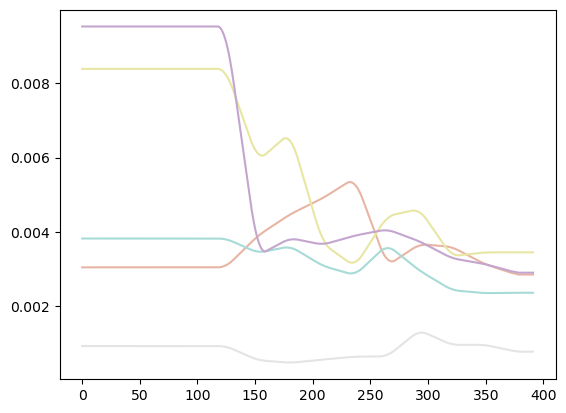

In [5]:
for r_idx in range(5):
    r = race_list_06[r_idx]
    plt.plot(ts_ifr_under65[:,r_idx],label=r,c=custom_colors[r])
    print(r_idx, r)

In [6]:
race_list_06

['asian', 'white', 'black', 'latino', 'other']

In [6]:
import copy
ts_ifr_over65_adj = copy.deepcopy(ts_ifr_over65)
ts_ifr_over65_adj[252:] = adjust_array(ts_ifr_over65_adj[252:], col_idx=1)

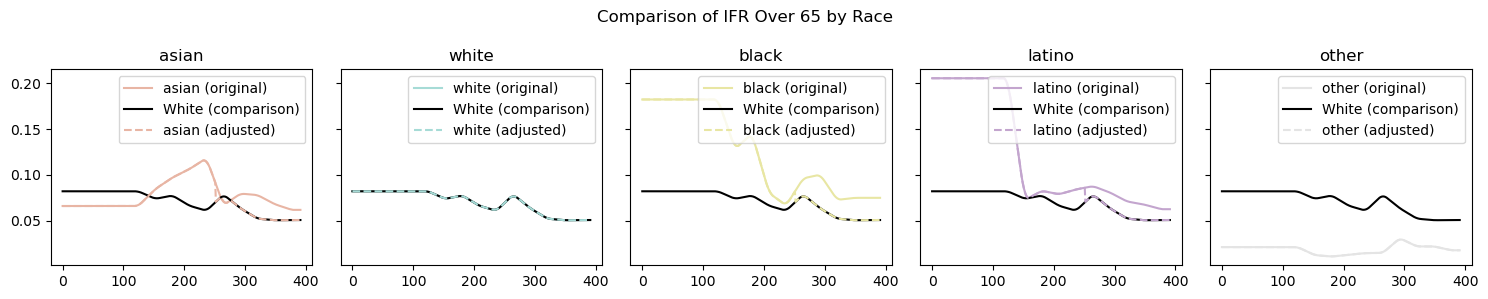

In [7]:
plot_ifr_comparison(ts_ifr_over65, ts_ifr_over65_adj,race_list_06, custom_colors, 'IFR Over 65')

In [8]:
ts_ifr_under65_adj = copy.deepcopy(ts_ifr_under65)
ts_ifr_under65_adj[252:] = adjust_array(ts_ifr_under65_adj[252:], col_idx=1)

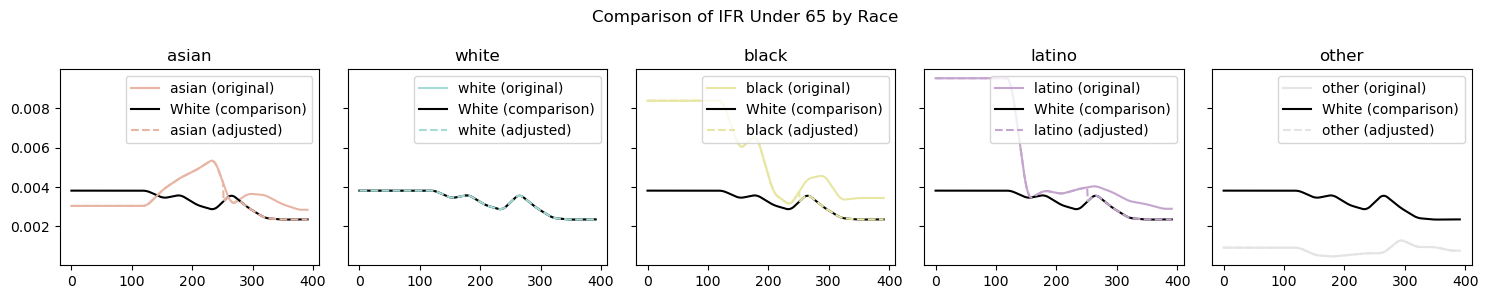

In [9]:
plot_ifr_comparison(ts_ifr_under65, ts_ifr_under65_adj,race_list_06, custom_colors, 'IFR Under 65')

In [10]:
ifr_adj_06 = ts_ifr_under65_adj*(1-prob_65over_06) + ts_ifr_over65_adj*prob_65over_06

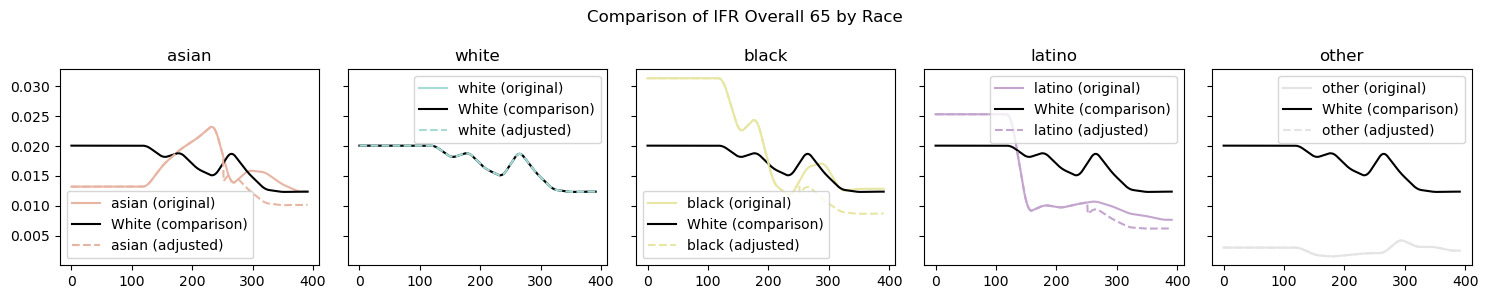

In [11]:
plot_ifr_comparison(ifr_06, ifr_adj_06,race_list_06, custom_colors, 'IFR Overall 65')

In [29]:
white_base = np.tile(ifr_06[252:,1][:, np.newaxis], (1, 5))
change_ifr_06 = (ifr_06[252:] - ifr_adj_06[252:])/(white_base)
# white_base.shape
print (list(zip(race_list_06,np.mean(change_ifr_06, axis=0)*100)))

[('asian', 21.143673293076986), ('white', -5.002873061136607e-15), ('black', 30.0197701079078), ('latino', 13.471540051446343), ('other', 8.021402506313823e-16)]


In [57]:
np.savetxt('my_ifr_ts-v6_06_adj.csv', ifr_adj_06, delimiter=',')

## Scenario B

In [58]:
M_beta_06 = np.loadtxt('beta_06_phase2_A.csv').reshape(200, 392, 5)

In [88]:
M_beta_06.shape

(200, 392, 5)

In [60]:
M_beta_06_adj = copy.deepcopy(M_beta_06)
for s_idx in range(M_beta_06.shape[0]):
    M_beta_06_adj[s_idx,252:] = adjust_array(M_beta_06_adj[s_idx,252:], col_idx=1)

In [61]:
M_beta_06_adj_median = np.median(M_beta_06_adj, axis=0)
M_beta_06_median = np.median(M_beta_06, axis=0)

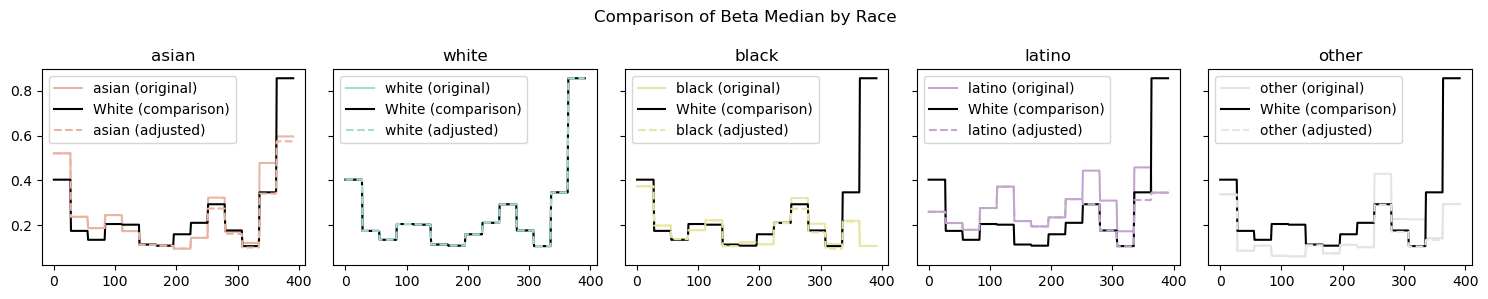

In [62]:
plot_ifr_comparison(M_beta_06_median, M_beta_06_adj_median,race_list_06, custom_colors, 'Beta Median')

In [63]:
np.savetxt('beta_06_phase2_A_adj.csv', M_beta_06_adj.reshape(-1, 5))

## location 37

In [3]:
ifr_37 = np.loadtxt('my_ifr_ts-v6_37.csv')

In [4]:
base = 1 - prob_65over_37 + prob_65over_37*ifr_ratio_37
ts_ifr_under65 = ifr_37/base
ts_ifr_over65 = ts_ifr_under65*ifr_ratio_37

0 asian
1 white
2 black
3 other


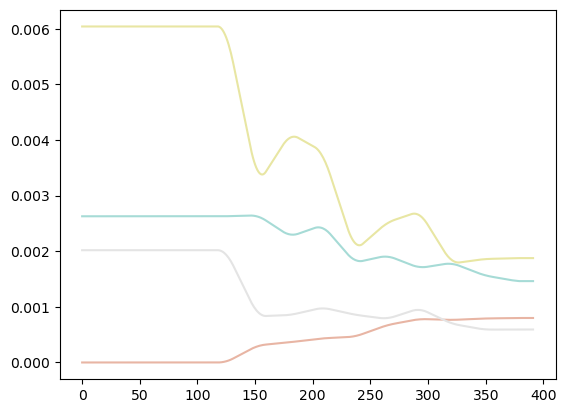

In [5]:
for r_idx in range(4):
    r = race_list_37[r_idx]
    plt.plot(ts_ifr_under65[:,r_idx],label=r,c=custom_colors[r])
    print(r_idx, r)

In [6]:
import copy
ts_ifr_over65_adj = copy.deepcopy(ts_ifr_over65)
ts_ifr_over65_adj[252:] = adjust_array(ts_ifr_over65_adj[252:], col_idx=1)

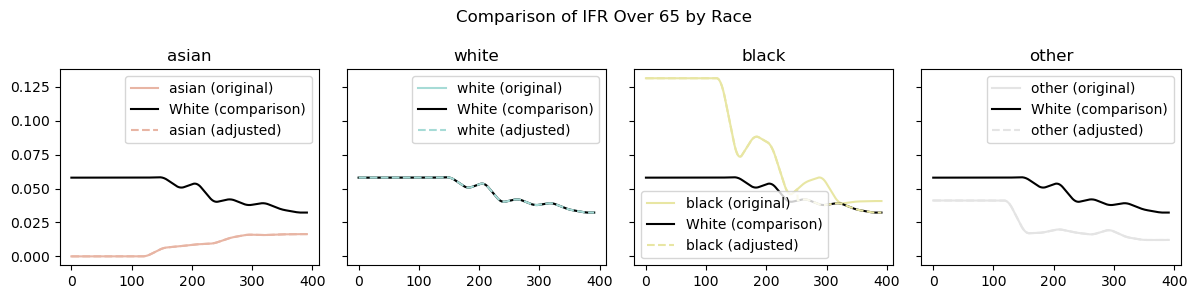

In [7]:
plot_ifr_comparison(ts_ifr_over65, ts_ifr_over65_adj,race_list_37, custom_colors, 'IFR Over 65')

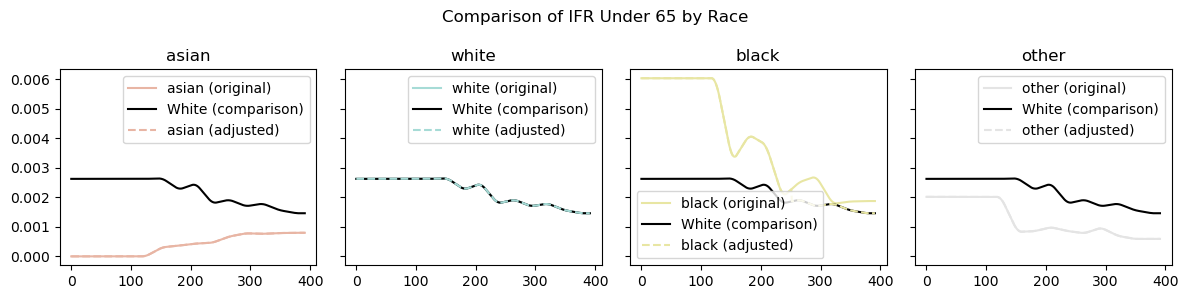

In [8]:
ts_ifr_under65_adj = copy.deepcopy(ts_ifr_under65)
ts_ifr_under65_adj[252:] = adjust_array(ts_ifr_under65_adj[252:], col_idx=1)
plot_ifr_comparison(ts_ifr_under65, ts_ifr_under65_adj,race_list_37, custom_colors, 'IFR Under 65')


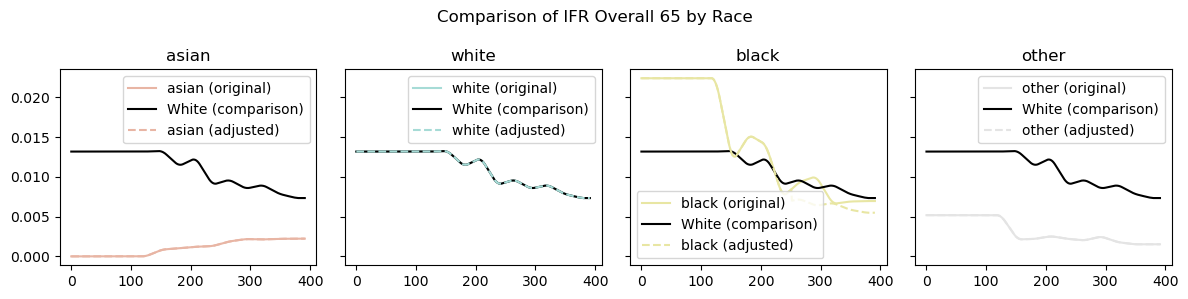

In [9]:
ifr_adj_37 = ts_ifr_under65_adj*(1-prob_65over_37) + ts_ifr_over65_adj*prob_65over_37
plot_ifr_comparison(ifr_37, ifr_adj_37,race_list_37, custom_colors, 'IFR Overall 65')

In [10]:
white_base = np.tile(ifr_37[252:,1][:, np.newaxis], (1, 4))
change_ifr_37 = (ifr_37[252:] - ifr_adj_37[252:])/(white_base)
# white_base.shape
print (list(zip(race_list_37,np.mean(change_ifr_37, axis=0)*100)))

[('asian', -9.302110676776132e-16), ('white', -5.472734653027858e-16), ('black', 18.818787408620217), ('other', -3.7976053741417527e-16)]


In [47]:
np.savetxt('my_ifr_ts-v6_37_adj.csv', ifr_adj_37, delimiter=',')

In [74]:
M_beta_37 = np.loadtxt('beta_37_phase2_A.csv').reshape(200, 392, 4)

In [75]:
M_beta_37_adj = copy.deepcopy(M_beta_37)
for s_idx in range(M_beta_37.shape[0]):
    M_beta_37_adj[s_idx,252:] = adjust_array(M_beta_37_adj[s_idx,252:], col_idx=1)

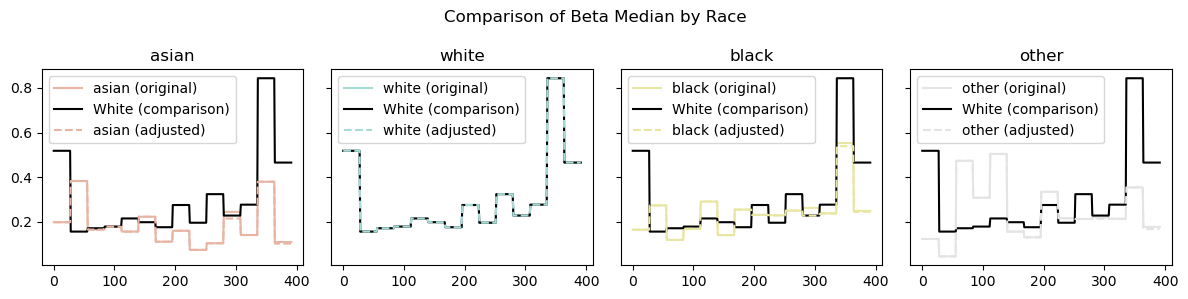

In [77]:
M_beta_37_adj_median = np.median(M_beta_37_adj, axis=0)
M_beta_37_median = np.median(M_beta_37, axis=0)
plot_ifr_comparison(M_beta_37_median, M_beta_37_adj_median,race_list_37, custom_colors, 'Beta Median')

In [78]:
np.savetxt('beta_37_phase2_A_adj.csv', M_beta_37_adj.reshape(-1, 4))